In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## Preparação dos dados

In [38]:
# Carregar dados
df = pd.read_csv(r'C:\\Users\Sofhia\Downloads\ML\tcc\tabela_final.csv', sep=',')

# Remover colunas não numéricas conforme solicitado
df = df.drop(columns=['order_delivered_carrier_date', 'order_delivered_customer_date', 'review_score'])

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33820 entries, 0 to 33819
Data columns (total 68 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   holiday_at_shipping                         33820 non-null  int64  
 1   approval_time_hours                         33820 non-null  float64
 2   handling_time_hours                         33820 non-null  float64
 3   shipping_delay_hours                        33820 non-null  float64
 4   delivery_time_days                          33820 non-null  float64
 5   purchase_hour                               33820 non-null  int64  
 6   purchase_day_of_week                        33820 non-null  int64  
 7   is_weekend                                  33820 non-null  int64  
 8   price                                       33820 non-null  float64
 9   freight_value                               33820 non-null  float64
 10  product_weight_g     

## Verificando nulos

In [40]:
# Mostra a quantidade de nulos em cada coluna
print(df.isnull().sum().sort_values(ascending=False))

holiday_at_shipping                   0
approval_time_hours                   0
handling_time_hours                   0
shipping_delay_hours                  0
delivery_time_days                    0
                                     ..
customer_meso_marilia                 0
customer_meso_assis                   0
customer_meso_aracatuba               0
customer_meso_itapetininga            0
customer_meso_litoral_sul_paulista    0
Length: 68, dtype: int64


## Heatmap para ver a maior correlação

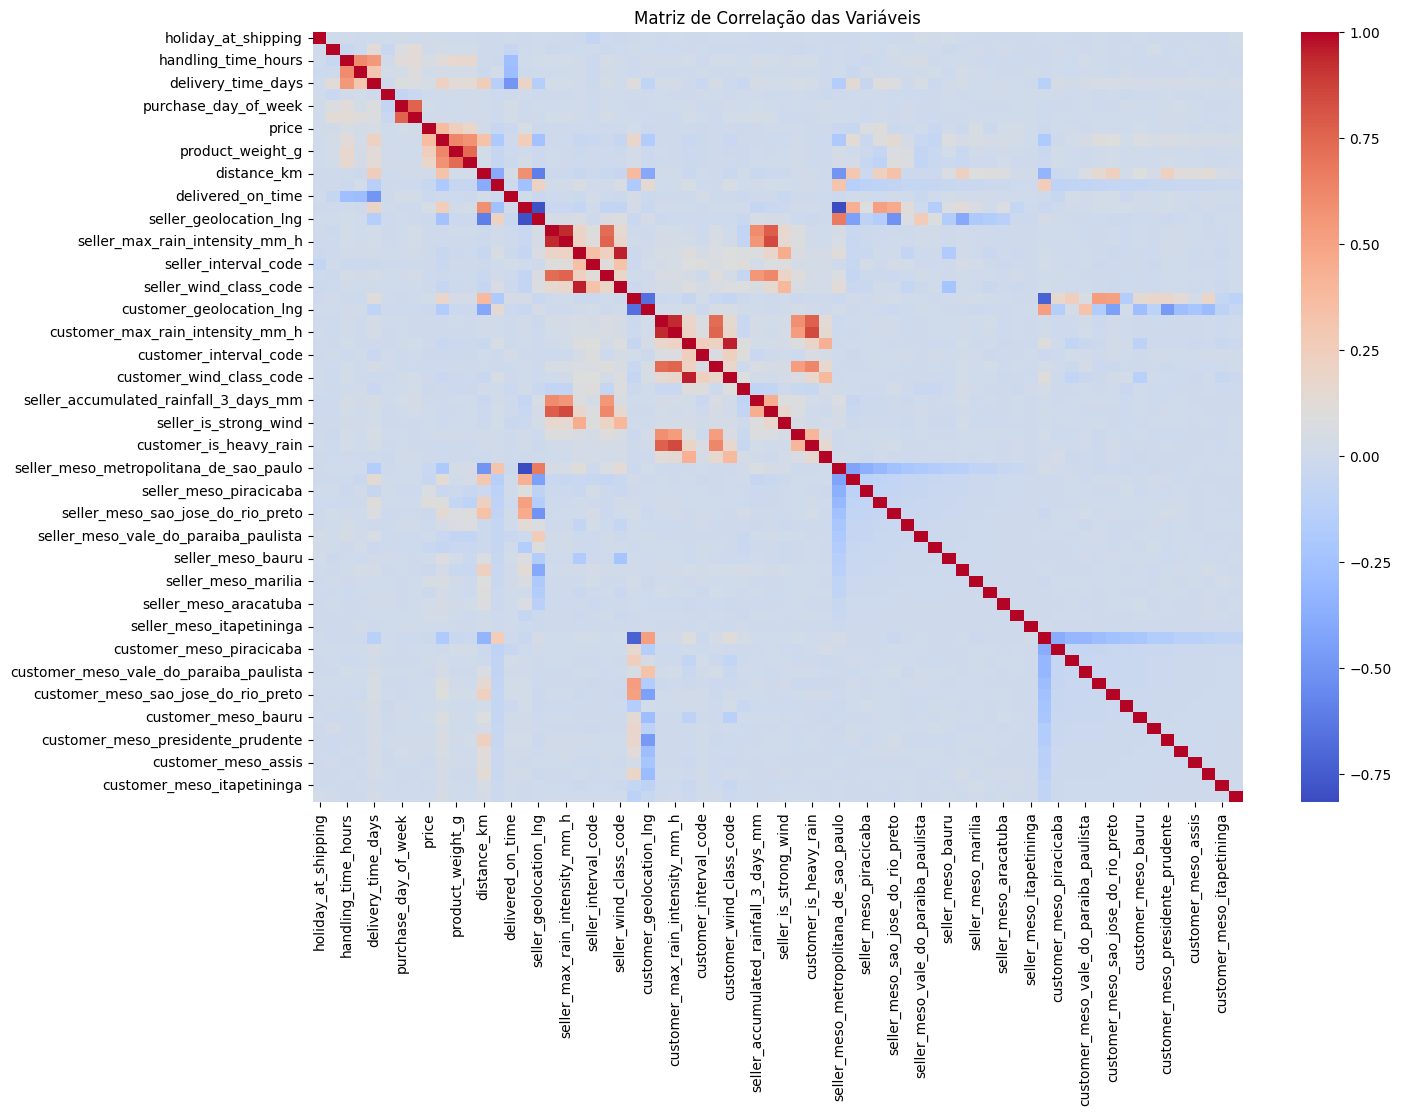

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Matriz de Correlação das Variáveis')
plt.show()

In [42]:
# Verificando a correlação
correlacao = df.corr()
print(correlacao['delivery_time_days'].sort_values(ascending=False).head(20))

delivery_time_days                         1.000000
handling_time_hours                        0.552036
shipping_delay_hours                       0.305505
distance_km                                0.252284
freight_value                              0.218740
seller_geolocation_lat                     0.193206
seller_meso_araraquara                     0.134724
volume_cm3                                 0.130162
product_weight_g                           0.123101
approval_time_hours                        0.122537
seller_meso_ribeirao_preto                 0.101953
customer_geolocation_lat                   0.100463
purchase_day_of_week                       0.082317
is_weekend                                 0.072852
seller_meso_sao_jose_do_rio_preto          0.071707
customer_accumulated_rainfall_3_days_mm    0.048849
price                                      0.046499
customer_meso_sao_jose_do_rio_preto        0.045677
seller_meso_vale_do_paraiba_paulista       0.043944
customer_mes

In [43]:
# Verificando a correlação
correlacao = df.corr()
print(correlacao['delivery_time_days'].sort_values(ascending=True).head(20))

delivered_on_time                          -0.496131
seller_meso_metropolitana_de_sao_paulo     -0.150848
seller_geolocation_lng                     -0.145391
same_city                                  -0.135635
customer_meso_metropolitana_de_sao_paulo   -0.133799
customer_geolocation_lng                   -0.090585
seller_meso_piracicaba                     -0.051934
customer_interval_code                     -0.039782
month                                      -0.039021
seller_meso_macro_metropolitana_paulista   -0.024867
seller_interval_code                       -0.020675
customer_wind_class_code                   -0.008056
customer_max_wind_gust_period_ms           -0.005934
seller_meso_itapetininga                   -0.003545
seller_meso_campinas                       -0.001824
customer_is_strong_wind                    -0.001549
purchase_hour                              -0.001271
seller_meso_assis                           0.000291
seller_meso_litoral_sul_paulista            0.

## Relacionando Variáveis
### 3 Variáveis com a maior correlação:
* `handling_time_hours` ->                       0.552036
* `shipping_delay_hours`  ->                     0.305505
* `distance_km`             ->                   0.252284

In [44]:
%pip install plotly
# importando as visualizações
import seaborn as sns
import plotly.express as px

Note: you may need to restart the kernel to use updated packages.


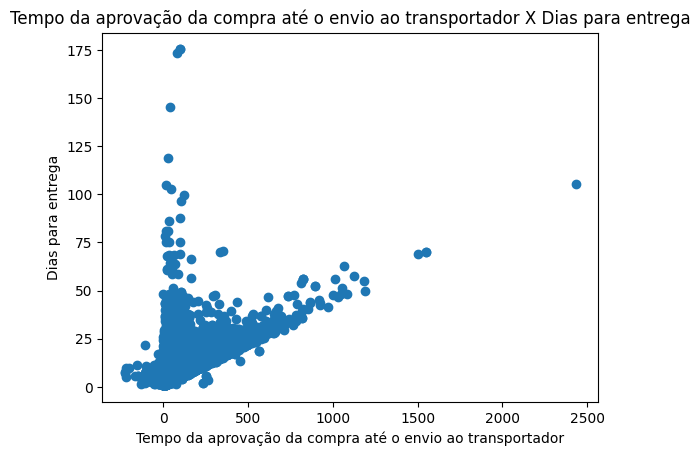

In [45]:
plt.scatter(df['handling_time_hours'], df['delivery_time_days'])
plt.title('Tempo da aprovação da compra até o envio ao transportador X Dias para entrega')
plt.xlabel('Tempo da aprovação da compra até o envio ao transportador')
plt.ylabel('Dias para entrega')
plt.show()

In [46]:
px.scatter(df, x = 'handling_time_hours', y = 'delivery_time_days', 
           trendline_color_override="red", trendline='ols')

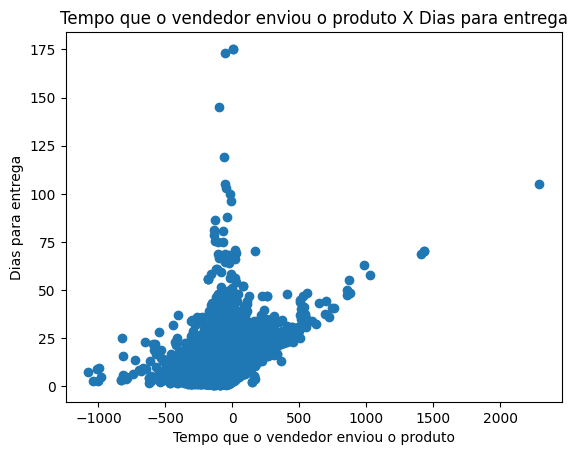

In [47]:
plt.scatter(df['shipping_delay_hours'], df['delivery_time_days'])
plt.title('Tempo que o vendedor enviou o produto X Dias para entrega')
plt.xlabel('Tempo que o vendedor enviou o produto')
plt.ylabel('Dias para entrega')
plt.show()

In [48]:
px.scatter(df, x = 'shipping_delay_hours', y = 'delivery_time_days', 
           trendline_color_override="red", trendline='ols')

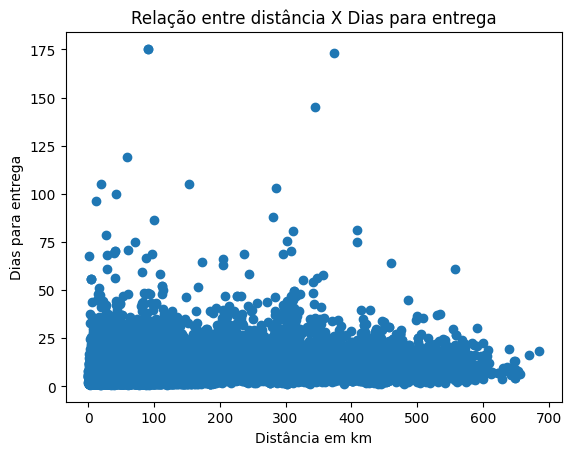

In [49]:
plt.scatter(df['distance_km'], df['delivery_time_days'])
plt.title('Relação entre distância X Dias para entrega')
plt.xlabel('Distância em km')
plt.ylabel('Dias para entrega')
plt.show()

In [50]:
px.scatter(df, x = 'distance_km', y = 'delivery_time_days', 
           trendline_color_override="red", trendline='ols')

## Distribuição do delivery_time_days 
### Utilizando histograma e boxplot

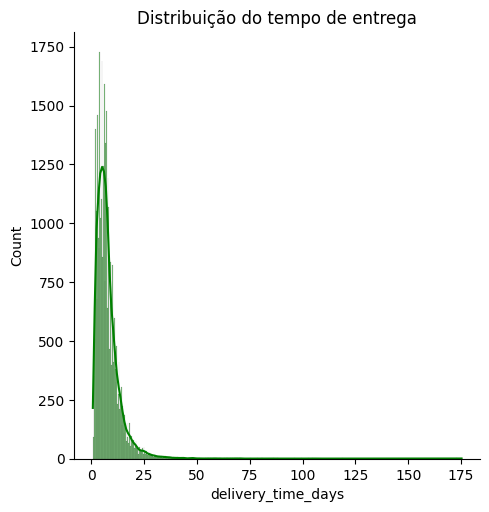

In [51]:
sns.displot(df['delivery_time_days'], kde=True, color='green')
plt.title('Distribuição do tempo de entrega')
plt.show()

Pode-se observar que o gráfico está assimétrico -> Influência desproporcional de valores altos: Valores muito grandes "puxam" a reta da regressão, prejudicando a precisão para a maioria dos dados.

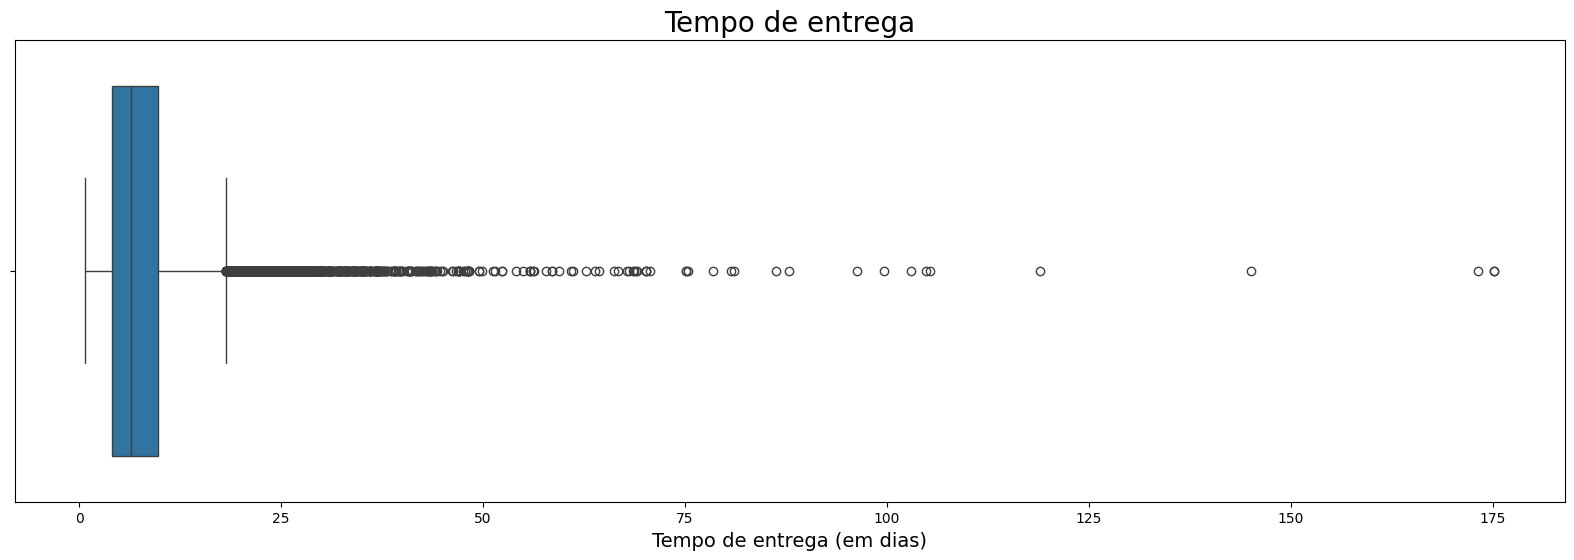

In [52]:
ax = sns.boxplot(x='delivery_time_days', data=df)

ax.figure.set_size_inches(20, 6)
ax.set_title('Tempo de entrega', fontsize=20)
ax.set_xlabel('Tempo de entrega (em dias)', fontsize=14)
plt.show()

## Analisando as variáveis independentes

In [53]:
df.columns

Index(['holiday_at_shipping', 'approval_time_hours', 'handling_time_hours',
       'shipping_delay_hours', 'delivery_time_days', 'purchase_hour',
       'purchase_day_of_week', 'is_weekend', 'price', 'freight_value',
       'product_weight_g', 'volume_cm3', 'distance_km', 'same_city',
       'delivered_on_time', 'seller_geolocation_lat', 'seller_geolocation_lng',
       'seller_total_rainfall_period_mm', 'seller_max_rain_intensity_mm_h',
       'seller_max_wind_gust_period_ms', 'seller_interval_code',
       'seller_rain_class_code', 'seller_wind_class_code',
       'customer_geolocation_lat', 'customer_geolocation_lng',
       'customer_total_rainfall_period_mm', 'customer_max_rain_intensity_mm_h',
       'customer_max_wind_gust_period_ms', 'customer_interval_code',
       'customer_rain_class_code', 'customer_wind_class_code', 'month',
       'seller_accumulated_rainfall_3_days_mm', 'seller_is_heavy_rain',
       'seller_is_strong_wind', 'customer_accumulated_rainfall_3_days_mm',
   

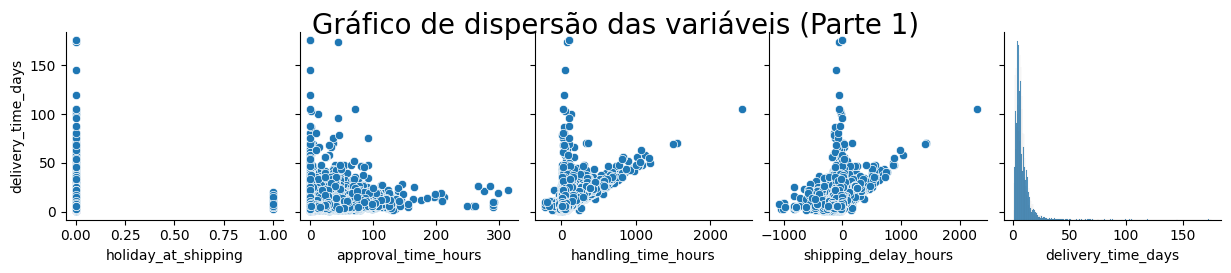

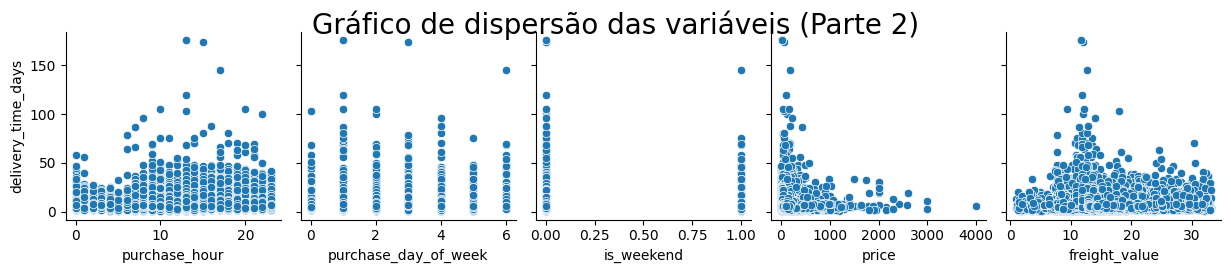

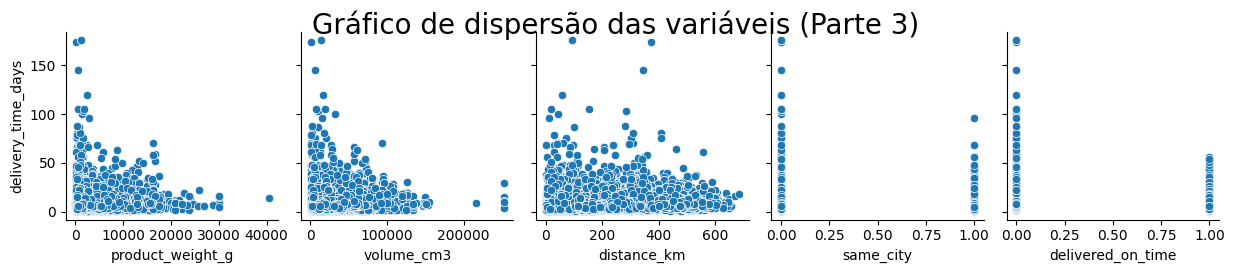

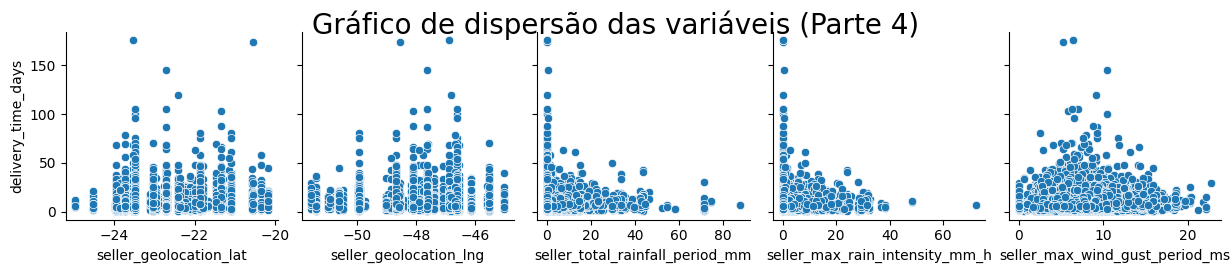

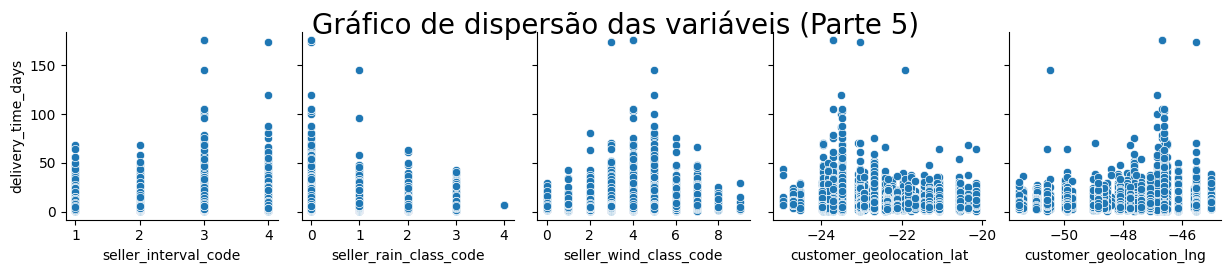

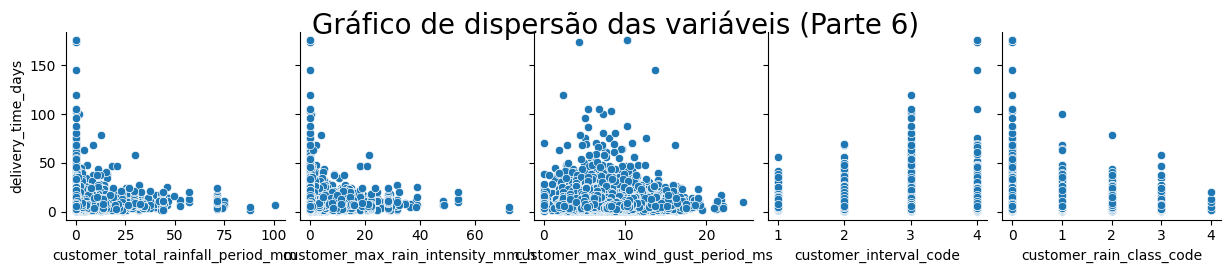

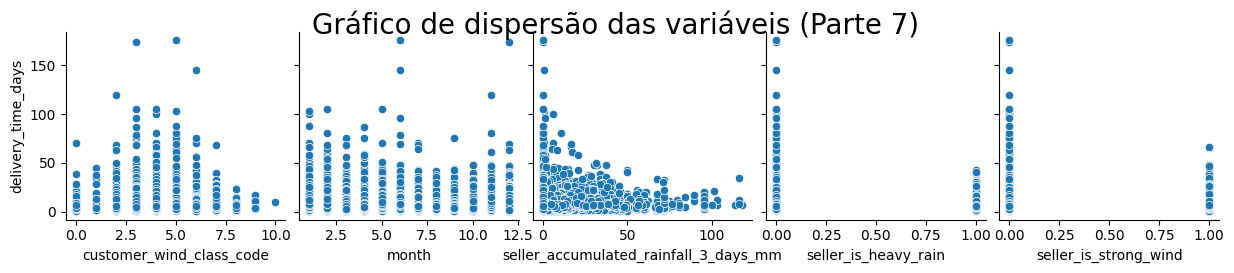

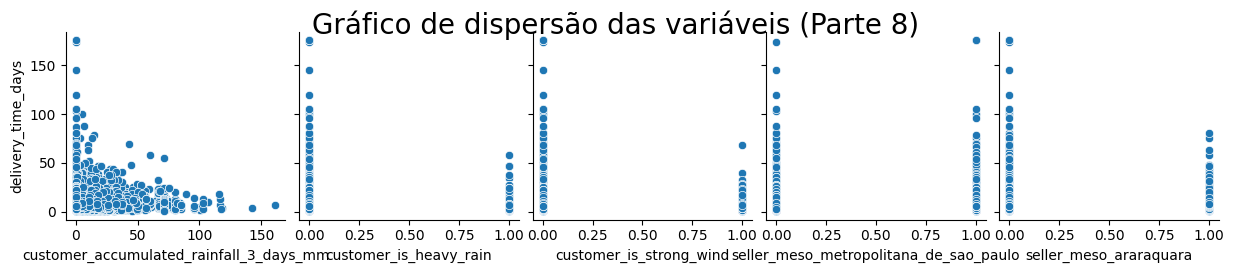

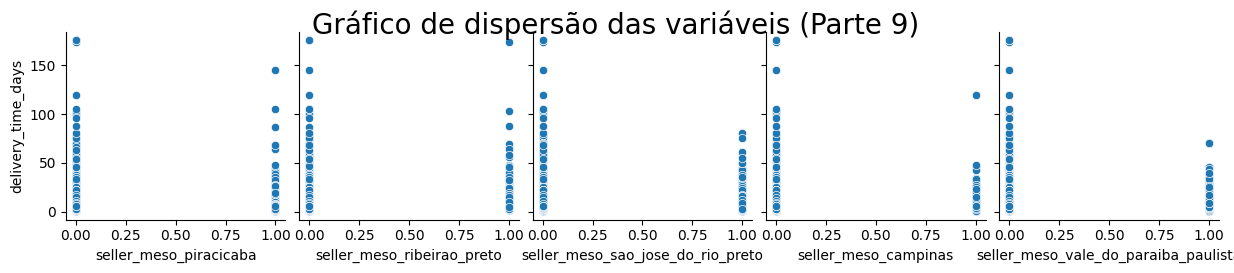

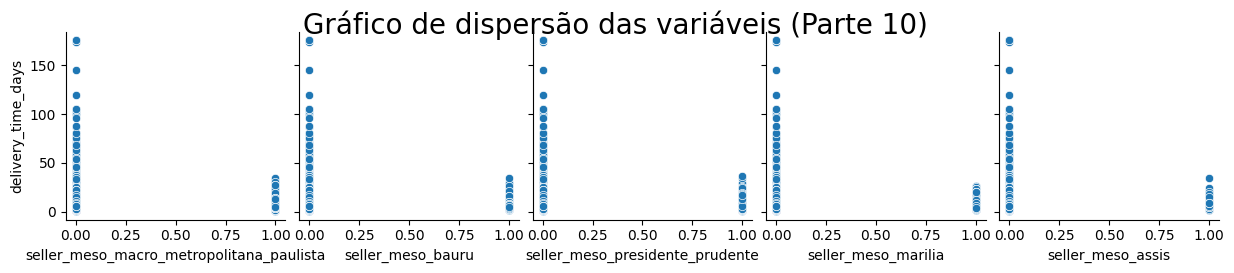

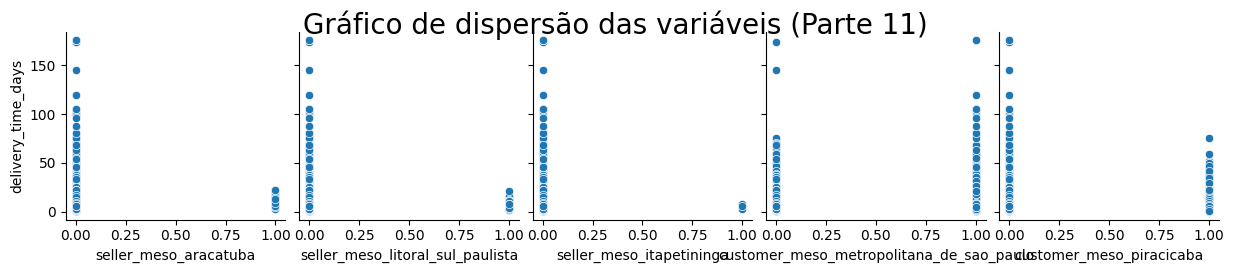

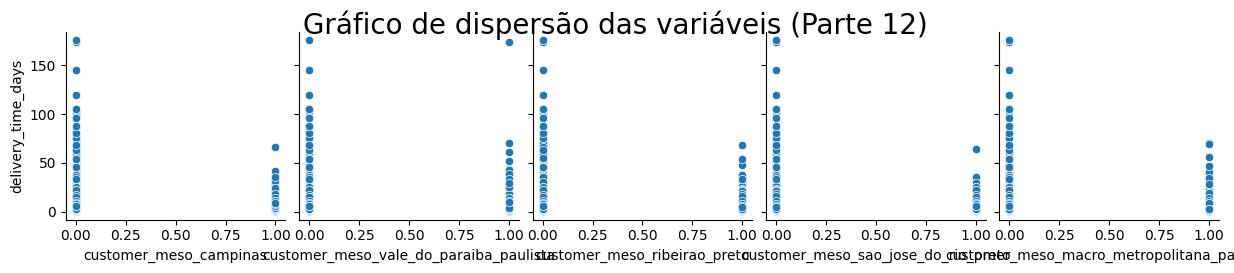

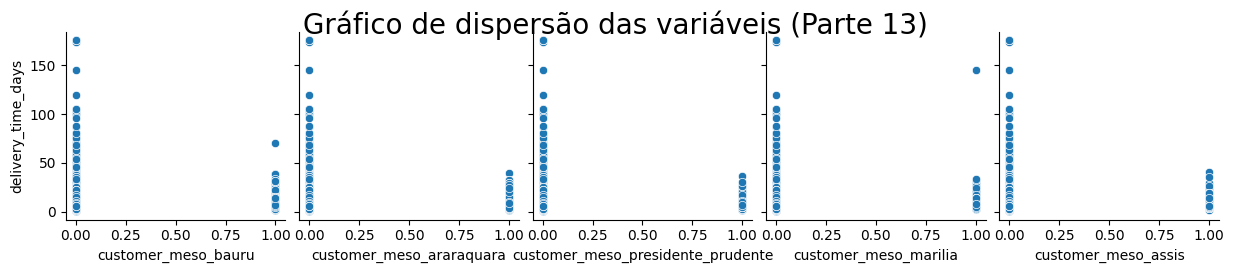

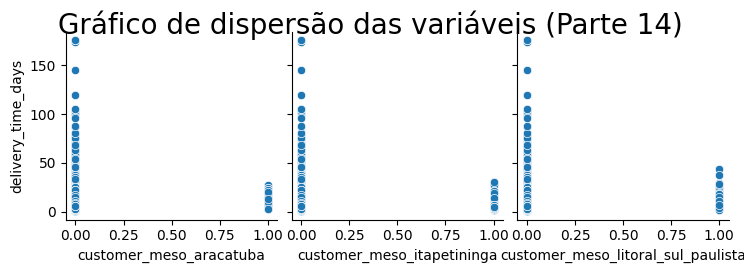

In [54]:
x_vars_list = ['holiday_at_shipping', 'approval_time_hours', 'handling_time_hours',
       'shipping_delay_hours', 'delivery_time_days', 'purchase_hour',
       'purchase_day_of_week', 'is_weekend', 'price', 'freight_value',
       'product_weight_g', 'volume_cm3', 'distance_km', 'same_city',
       'delivered_on_time', 'seller_geolocation_lat',
       'seller_geolocation_lng', 'seller_total_rainfall_period_mm',
       'seller_max_rain_intensity_mm_h', 'seller_max_wind_gust_period_ms',
       'seller_interval_code', 'seller_rain_class_code',
       'seller_wind_class_code', 'customer_geolocation_lat',
       'customer_geolocation_lng', 'customer_total_rainfall_period_mm',
       'customer_max_rain_intensity_mm_h', 'customer_max_wind_gust_period_ms',
       'customer_interval_code', 'customer_rain_class_code',
       'customer_wind_class_code', 'month',
       'seller_accumulated_rainfall_3_days_mm', 'seller_is_heavy_rain',
       'seller_is_strong_wind', 'customer_accumulated_rainfall_3_days_mm',
       'customer_is_heavy_rain', 'customer_is_strong_wind',
       'seller_meso_metropolitana_de_sao_paulo', 'seller_meso_araraquara',
       'seller_meso_piracicaba', 'seller_meso_ribeirao_preto',
       'seller_meso_sao_jose_do_rio_preto', 'seller_meso_campinas',
       'seller_meso_vale_do_paraiba_paulista',
       'seller_meso_macro_metropolitana_paulista', 'seller_meso_bauru',
       'seller_meso_presidente_prudente', 'seller_meso_marilia',
       'seller_meso_assis', 'seller_meso_aracatuba',
       'seller_meso_litoral_sul_paulista', 'seller_meso_itapetininga',
       'customer_meso_metropolitana_de_sao_paulo', 'customer_meso_piracicaba',
       'customer_meso_campinas', 'customer_meso_vale_do_paraiba_paulista',
       'customer_meso_ribeirao_preto', 'customer_meso_sao_jose_do_rio_preto',
       'customer_meso_macro_metropolitana_paulista', 'customer_meso_bauru',
       'customer_meso_araraquara', 'customer_meso_presidente_prudente',
       'customer_meso_marilia', 'customer_meso_assis',
       'customer_meso_aracatuba', 'customer_meso_itapetininga',
       'customer_meso_litoral_sul_paulista']

for i in range(0, len(x_vars_list), 5):
    ax = sns.pairplot(df, y_vars="delivery_time_days", x_vars=x_vars_list[i:i+5])
    ax.figure.suptitle(f'Gráfico de dispersão das variáveis (Parte {i//5 + 1})', y=1.05, fontsize=20)
    plt.show()

### Refazendo a lista: retiramos as variáveis binárias

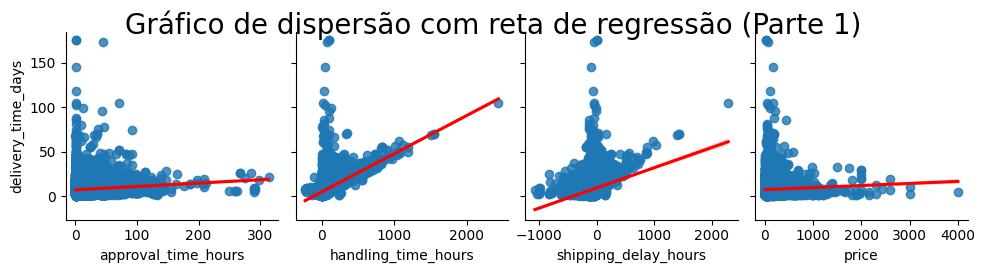

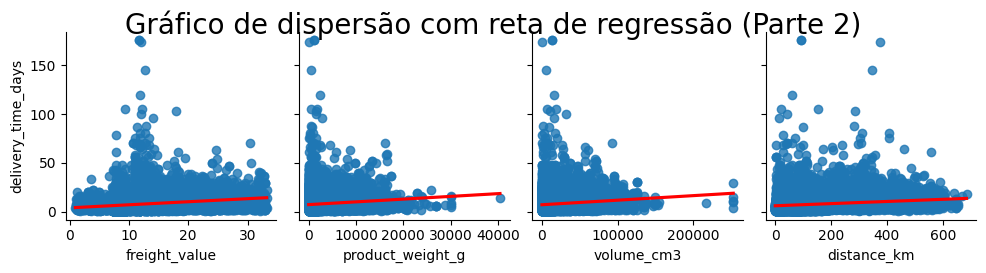

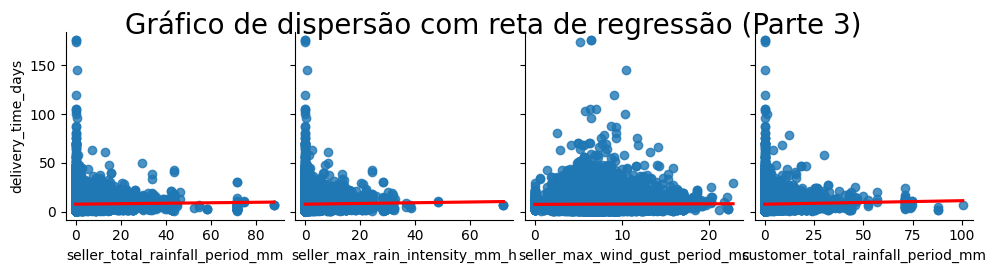

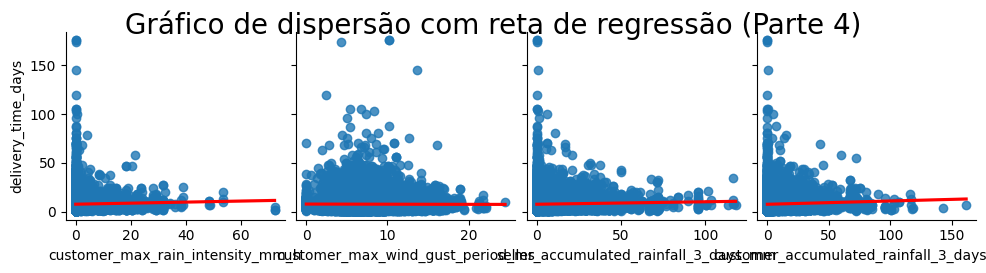

In [55]:
x_vars_list_reg = ['approval_time_hours', 'handling_time_hours',
       'shipping_delay_hours', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 
       'distance_km', 'seller_total_rainfall_period_mm', 'seller_max_rain_intensity_mm_h', 'seller_max_wind_gust_period_ms',
       'customer_total_rainfall_period_mm','customer_max_rain_intensity_mm_h', 'customer_max_wind_gust_period_ms',
       'seller_accumulated_rainfall_3_days_mm', 'customer_accumulated_rainfall_3_days_mm']

# Pairplot com reta de regressão dividindo em até 4 gráficos por linha
for i in range(0, len(x_vars_list_reg), 4):
    ax = sns.pairplot(df, y_vars="delivery_time_days", x_vars=x_vars_list_reg[i:i+4],
                      kind='reg', plot_kws={'line_kws':{'color':'red'}})
    ax.figure.suptitle(f'Gráfico de dispersão com reta de regressão (Parte {i//4 + 1})', y=1.05, fontsize=20)
    plt.show()

## Aplicando transformação logarítmica

In [56]:
df.describe().round(2)

,holiday_at_shipping,approval_time_hours,handling_time_hours,shipping_delay_hours,delivery_time_days,purchase_hour,purchase_day_of_week,is_weekend,price,freight_value,...,customer_meso_sao_jose_do_rio_preto,customer_meso_macro_metropolitana_paulista,customer_meso_bauru,customer_meso_araraquara,customer_meso_presidente_prudente,customer_meso_marilia,customer_meso_assis,customer_meso_aracatuba,customer_meso_itapetininga,customer_meso_litoral_sul_paulista
count,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,...,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00
mean,0.00,9.90,65.18,-78.37,7.82,14.71,2.89,0.24,91.97,12.02,...,0.03,0.03,0.02,0.01,0.01,0.01,0.01,0.01,0.00,0.00
std,0.03,19.99,78.65,82.66,6.12,5.33,1.88,0.43,122.81,4.30,...,0.17,0.16,0.15,0.11,0.11,0.09,0.08,0.08,0.06,0.06
min,0.00,0.00,-224.93,-1076.81,0.78,0.00,0.00,0.00,1.20,0.98,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.22,21.03,-123.72,4.13,11.00,1.00,0.00,32.99,8.72,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.35,42.84,-76.22,6.46,15.00,3.00,0.00,59.90,11.85,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.00,13.07,84.08,-35.26,9.76,19.00,4.00,0.00,109.90,13.64,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,313.80,2432.67,2288.67,175.22,23.00,6.00,1.00,3999.90,33.22,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [57]:
cols = ["delivery_time_days",
    "approval_time_hours",
    "handling_time_hours",
    "shipping_delay_hours",
    "price",
    "freight_value",
    "product_weight_g",
    "volume_cm3",
    "distance_km",
    "seller_total_rainfall_period_mm",
    "seller_max_rain_intensity_mm_h",
    "seller_max_wind_gust_period_ms",
    "customer_total_rainfall_period_mm",
    "customer_max_rain_intensity_mm_h",
    "customer_max_wind_gust_period_ms",
    "seller_accumulated_rainfall_3_days_mm",
    "customer_accumulated_rainfall_3_days_mm",
]

df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
delivery_time_days,33820.0,7.816442,6.124319,0.781,4.12800,6.4560,9.7650,175.224
approval_time_hours,33820.0,9.898727,19.994124,0.000,0.21800,0.3485,13.0665,313.799
handling_time_hours,33820.0,65.176783,78.653135,-224.930,21.03150,42.8380,84.0785,2432.671
shipping_delay_hours,33820.0,-78.367635,82.663164,-1076.806,-123.72225,-76.2160,-35.2580,2288.671
price,33820.0,91.973878,122.810337,1.200,32.99000,59.9000,109.9000,3999.900
freight_value,33820.0,12.018414,4.298559,0.980,8.72000,11.8500,13.6400,33.220
product_weight_g,33820.0,1612.396008,2692.113177,0.000,250.00000,600.0000,1550.0000,40425.000
volume_cm3,33820.0,12874.944116,17076.196077,352.000,2601.00000,5832.0000,16206.0000,252402.000
distance_km,33820.0,148.362396,140.848912,0.078,28.86900,93.6730,264.0665,685.461
seller_total_rainfall_period_mm,33820.0,1.042969,4.726192,0.000,0.00000,0.0000,0.0000,87.800


Aplicando log1p para os que tiveram min = 0.00, para o Python não retornar erro ou valores -inf

In [58]:
df['log_delivery_time_days'] = np.log1p(df['delivery_time_days'])
df['log_approval_time_hours'] = np.log(df['approval_time_hours'])
df['log_handling_time_hours'] = np.log1p(df['handling_time_hours'])
df['log_shipping_delay_hours'] = np.log1p(df['shipping_delay_hours'])
df['log_price'] = np.log1p(df['price'])
df['log_freight_value'] = np.log1p(df['freight_value'])
df['log_product_weight_g'] = np.log(df['product_weight_g'])
df['log_volume_cm3'] = np.log1p(df['volume_cm3'])
df['log_distance_km'] = np.log1p(df['distance_km'])
df['log_seller_total_rainfall_period_mm'] = np.log(df['seller_total_rainfall_period_mm'])
df['log_seller_max_rain_intensity_mm_h'] = np.log(df['seller_max_rain_intensity_mm_h'])
df['log_seller_max_wind_gust_period_ms'] = np.log(df['seller_max_wind_gust_period_ms'])
df['log_customer_total_rainfall_period_mm'] = np.log(df['customer_total_rainfall_period_mm'])
df['log_customer_max_rain_intensity_mm_h'] = np.log(df['customer_max_rain_intensity_mm_h'])
df['log_customer_max_wind_gust_period_ms'] = np.log(df['customer_max_wind_gust_period_ms'])
df['log_seller_accumulated_rainfall_3_days_mm'] = np.log(df['seller_accumulated_rainfall_3_days_mm'])
df['log_customer_accumulated_rainfall_3_days_mm'] = np.log(df['customer_accumulated_rainfall_3_days_mm'])

c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [59]:
df.head()

,holiday_at_shipping,approval_time_hours,handling_time_hours,shipping_delay_hours,delivery_time_days,purchase_hour,purchase_day_of_week,is_weekend,price,freight_value,...,log_volume_cm3,log_distance_km,log_seller_total_rainfall_period_mm,log_seller_max_rain_intensity_mm_h,log_seller_max_wind_gust_period_ms,log_customer_total_rainfall_period_mm,log_customer_max_rain_intensity_mm_h,log_customer_max_wind_gust_period_ms,log_seller_accumulated_rainfall_3_days_mm,log_customer_accumulated_rainfall_3_days_mm
0,0,13.500,60.241,-22.259,5.921,14,5,1,29.99,4.50,...,7.204149,4.931318,-inf,-inf,2.014903,-inf,-inf,2.261763,-inf,0.182322
1,0,13.500,60.241,-22.259,5.921,14,5,1,29.99,4.50,...,7.204149,4.931318,-inf,-inf,2.014903,-inf,-inf,2.261763,-inf,0.182322
2,0,13.500,60.241,-22.259,5.921,14,5,1,29.99,4.50,...,7.204149,4.931318,-inf,-inf,2.014903,-inf,-inf,2.261763,-inf,0.182322
3,0,13.500,60.241,-22.259,5.921,14,5,1,29.99,4.50,...,7.204149,4.931318,-inf,-inf,2.014903,-inf,-inf,2.261763,-inf,0.182322
4,0,73.354,55.075,32.430,11.551,2,6,1,239.00,12.28,...,7.902857,4.411185,-inf,-inf,2.014903,-inf,-inf,1.704748,-inf,-inf


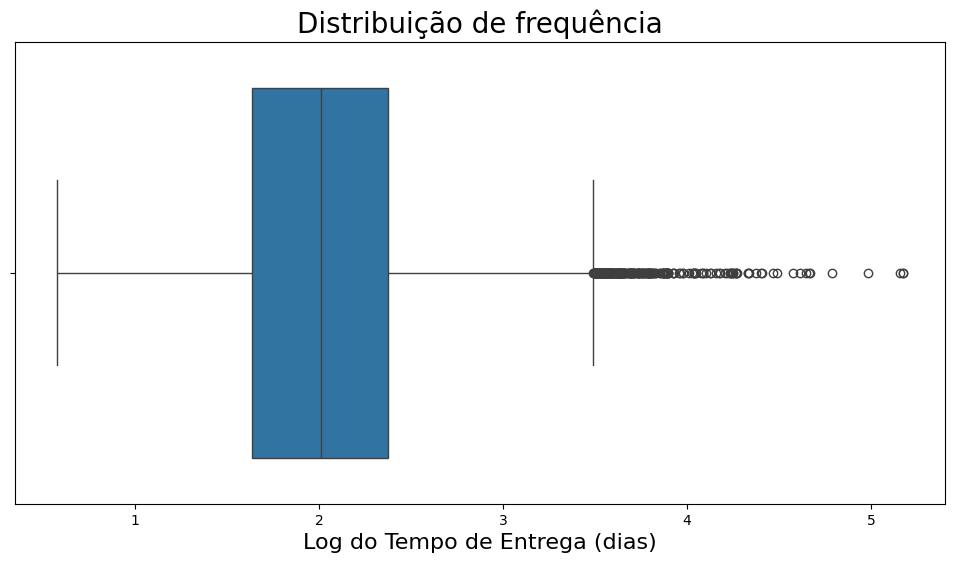

In [60]:
ax = sns.boxplot(x='log_delivery_time_days', data=df)

ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de frequência', fontsize=20)
ax.set_xlabel('Log do Tempo de Entrega (dias)', fontsize=16)
plt.show()

Diminuiu a assimetria

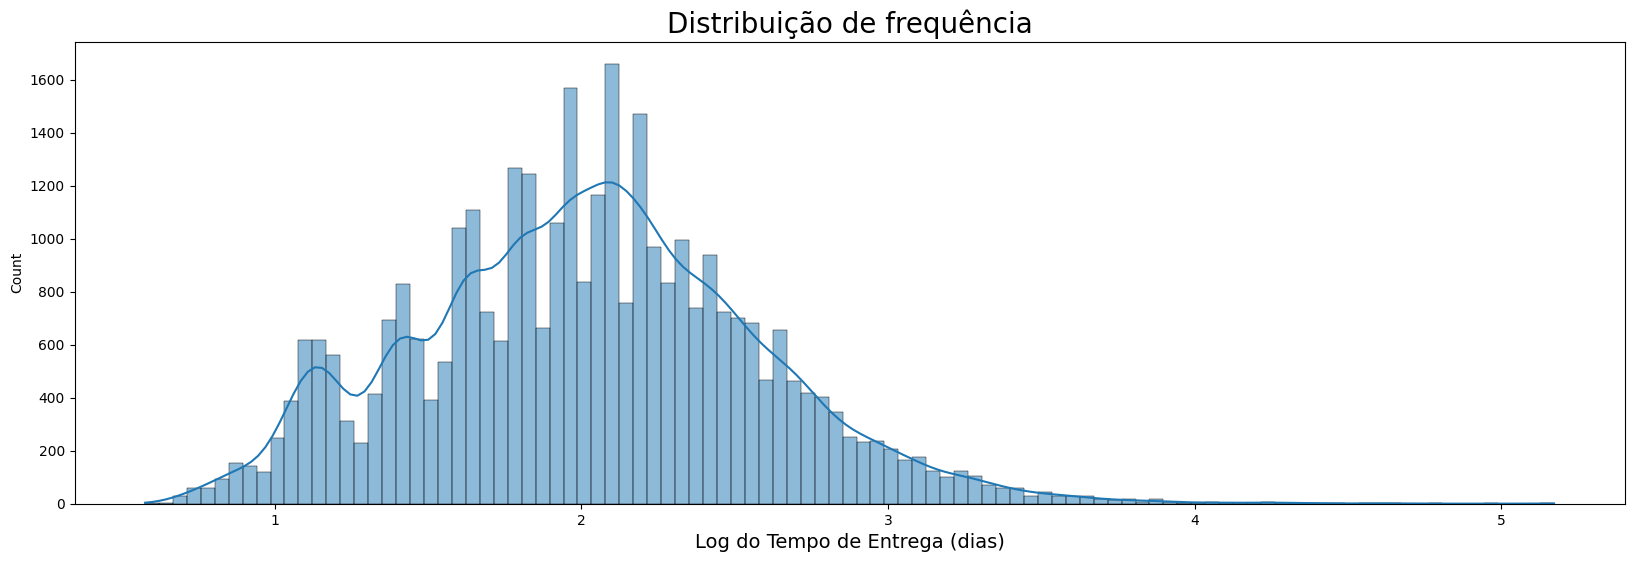

In [61]:
ax = sns.histplot(x='log_delivery_time_days', data=df, kde=True)
ax.figure.set_size_inches(20, 6)
ax.set_title('Distribuição de frequência', fontsize=20)
ax.set_xlabel('Log do Tempo de Entrega (dias)', fontsize=14)
plt.show()

c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\function_base.py:172: RuntimeWarning: invalid value encountered in add
  y += start
c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


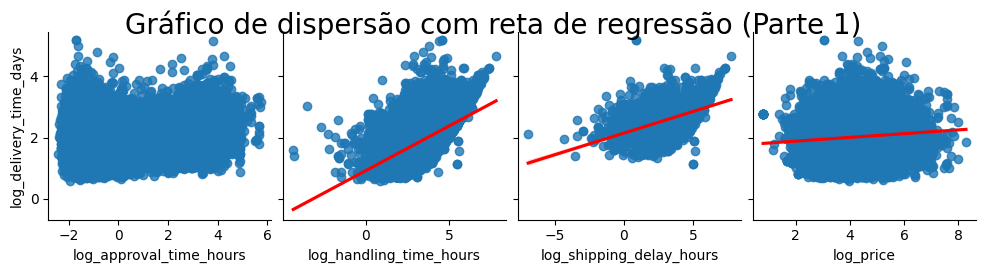

c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\function_base.py:172: RuntimeWarning: invalid value encountered in add
  y += start
c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


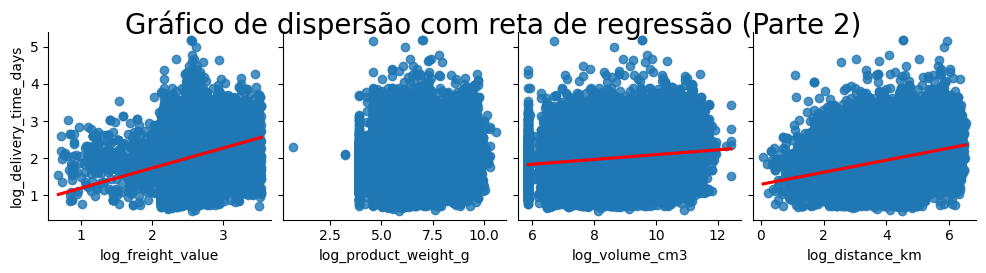

c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\function_base.py:172: RuntimeWarning: invalid value encountered in add
  y += start
c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


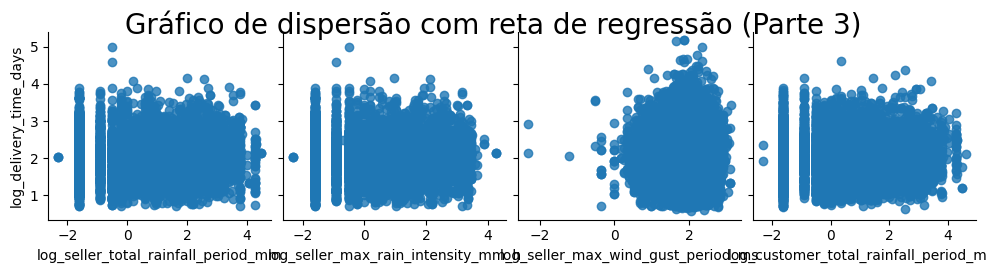

c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\function_base.py:172: RuntimeWarning: invalid value encountered in add
  y += start
c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


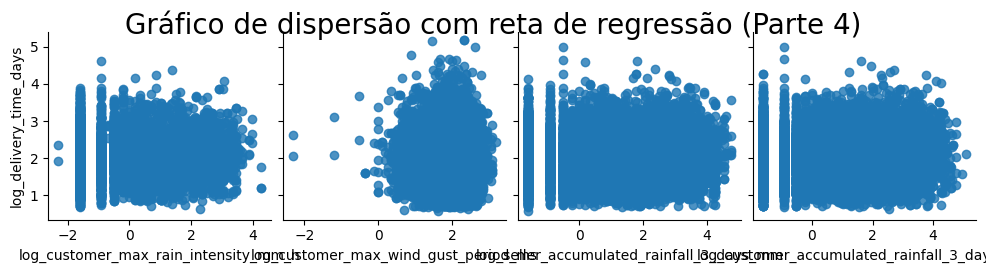

In [62]:
x_vars_list_reg = ['log_approval_time_hours', 'log_handling_time_hours',
       'log_shipping_delay_hours', 'log_price', 'log_freight_value', 'log_product_weight_g', 'log_volume_cm3', 
       'log_distance_km', 'log_seller_total_rainfall_period_mm', 'log_seller_max_rain_intensity_mm_h', 'log_seller_max_wind_gust_period_ms',
       'log_customer_total_rainfall_period_mm','log_customer_max_rain_intensity_mm_h', 'log_customer_max_wind_gust_period_ms',
       'log_seller_accumulated_rainfall_3_days_mm', 'log_customer_accumulated_rainfall_3_days_mm']

for i in range(0, len(x_vars_list_reg), 4):
    ax = sns.pairplot(df, y_vars="log_delivery_time_days", x_vars=x_vars_list_reg[i:i+4],
                      kind='reg', plot_kws={'line_kws':{'color':'red'}})
    ax.figure.suptitle(f'Gráfico de dispersão com reta de regressão (Parte {i//4 + 1})', y=1.05, fontsize=20)
    plt.show()

## Definição das variáveis X e y
* X = variáveis explicativas
* y = variável que queremos prever

In [63]:
# Variável dependente (o que queremos prever)
y = df['delivery_time_days']

# Variáveis independentes (todas as outras colunas numéricas)
X = df[['approval_time_hours', 'handling_time_hours',
       'shipping_delay_hours', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 
       'distance_km', 'seller_total_rainfall_period_mm', 'seller_max_rain_intensity_mm_h', 'seller_max_wind_gust_period_ms',
       'customer_total_rainfall_period_mm','customer_max_rain_intensity_mm_h', 'customer_max_wind_gust_period_ms',
       'seller_accumulated_rainfall_3_days_mm', 'customer_accumulated_rainfall_3_days_mm']]

In [73]:
# Remove linhas com NaN/inf nas variaveis originais
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask]
y = y.loc[mask]

Divisão em treino e teste

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Treinando o modelo

In [65]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Avaliação do modelo

In [66]:
# Realizar previsões
previsoes = modelo.predict(X_train)

# Métrica R²
print(f"R² Score: {metrics.r2_score(y_train, previsoes)}")

R² Score: 0.3849613397953582


In [67]:
# Realizar previsões
previsoes_test = modelo.predict(X_test)

# Métrica R²
print(f"R² Score: {metrics.r2_score(y_test, previsoes_test)}")

R² Score: 0.4532365887404204


In [68]:
# Variável dependente (o que queremos prever)
y_log = df['log_delivery_time_days']

# Variáveis independentes (todas as outras colunas numéricas)
X_log = df[['log_approval_time_hours', 'log_handling_time_hours',
       'log_shipping_delay_hours', 'log_price', 'log_freight_value', 'log_product_weight_g', 'log_volume_cm3', 
       'log_distance_km', 'log_seller_total_rainfall_period_mm', 'log_seller_max_rain_intensity_mm_h', 'log_seller_max_wind_gust_period_ms',
       'log_customer_total_rainfall_period_mm','log_customer_max_rain_intensity_mm_h', 'log_customer_max_wind_gust_period_ms',
       'log_seller_accumulated_rainfall_3_days_mm', 'log_customer_accumulated_rainfall_3_days_mm']]

In [69]:
# Remove linhas com NaN/inf nas variaveis log
X_log = X_log.replace([np.inf, -np.inf], np.nan)
y_log = y_log.replace([np.inf, -np.inf], np.nan)
mask = X_log.notna().all(axis=1) & y_log.notna()
X_log = X_log.loc[mask]
y_log = y_log.loc[mask]

In [70]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.25, random_state=42)

In [71]:
modelo = LinearRegression()
modelo.fit(X_train_log, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
# Realizar previsões
previsoes_log = modelo.predict(X_train_log)

# Métrica R²
print(f"R² Score: {metrics.r2_score(y_train_log, previsoes_log)}")

R² Score: 0.7147915830468826


In [78]:
# Realizar previsões
previsoes_log_test = modelo.predict(X_test_log)

# Métrica R²
print(f"R² Score: {metrics.r2_score(y_test_log, previsoes_log_test)}")

R² Score: 0.7088986711398436


In [74]:
from sklearn.preprocessing import StandardScaler

# 1. Selecionar as colunas que você transformou em log
colunas_log = [
    'log_approval_time_hours', 'log_handling_time_hours', 'log_shipping_delay_hours',
    'log_price', 'log_freight_value', 'log_product_weight_g', 'log_volume_cm3',
    'log_distance_km', 'log_seller_total_rainfall_period_mm', 
    'log_seller_max_rain_intensity_mm_h', 'log_seller_max_wind_gust_period_ms',
    'log_customer_total_rainfall_period_mm', 'log_customer_max_rain_intensity_mm_h',
    'log_customer_max_wind_gust_period_ms', 'log_seller_accumulated_rainfall_3_days_mm',
    'log_customer_accumulated_rainfall_3_days_mm'
]

# 2. Inicializar o Scaler
scaler = StandardScaler()

# 3. Ajustar no treino e transformar treino e teste
# Importante: O scaler retorna um array numpy, então reconvertemos para DataFrame para manter os nomes das colunas
X_train_scaled = X_train_log.copy()
X_test_scaled = X_test_log.copy()

X_train_scaled[colunas_log] = scaler.fit_transform(X_train_log[colunas_log])
X_test_scaled[colunas_log] = scaler.transform(X_test_log[colunas_log])

# 4. Treinar o modelo com os dados padronizados
modelo_final = LinearRegression()
modelo_final.fit(X_train_scaled, y_train_log)

# 5. Criar um DataFrame para ver a importância das variáveis
importancia = pd.DataFrame({
    'Variavel': X_train_scaled.columns,
    'Coeficiente': modelo_final.coef_
}).sort_values(by='Coeficiente', ascending=False)

print(importancia)

                                       Variavel  Coeficiente
1                       log_handling_time_hours     0.371316
8           log_seller_total_rainfall_period_mm     0.165202
7                               log_distance_km     0.112348
0                       log_approval_time_hours     0.108731
10           log_seller_max_wind_gust_period_ms     0.058644
12         log_customer_max_rain_intensity_mm_h     0.056467
6                                log_volume_cm3     0.053178
4                             log_freight_value     0.037755
13         log_customer_max_wind_gust_period_ms     0.019049
5                          log_product_weight_g     0.003481
11        log_customer_total_rainfall_period_mm    -0.006729
15  log_customer_accumulated_rainfall_3_days_mm    -0.026463
3                                     log_price    -0.036258
14    log_seller_accumulated_rainfall_3_days_mm    -0.069022
2                      log_shipping_delay_hours    -0.074382
9            log_seller_

# Resultado: 75% treino e 25% teste

In [ ]:
from sklearn.metrics import r2_score

# --- 1. MODELO NORMAL (Sem Log) ---
modelo_normal = LinearRegression()
modelo_normal.fit(X_train, y_train)

r2_treino_normal = r2_score(y_train, modelo_normal.predict(X_train))
r2_teste_normal = r2_score(y_test, modelo_normal.predict(X_test))

# --- 2. MODELO COM LOG (+ StandardScaler) ---
modelo_log = LinearRegression()
modelo_log.fit(X_train_scaled, y_train_log)

r2_treino_log = r2_score(y_train_log, modelo_log.predict(X_train_scaled))
r2_teste_log = r2_score(y_test_log, modelo_log.predict(X_test_scaled))

# --- EXIBIÇÃO DOS RESULTADOS ---
print("=== COMPARATIVO DE PERFORMANCE (R²) ===")
print(f"{'Modelo':<20} | {'Treino':<10} | {'Teste':<10}")
print("-" * 45)
print(f"{'Original (Linear)':<20} | {r2_treino_normal:.4f}     | {r2_teste_normal:.4f}")
print(f"{'Log-Log (Ajustado)':<20} | {r2_treino_log:.4f}     | {r2_teste_log:.4f}")

=== COMPARATIVO DE PERFORMANCE (R²) ===
Modelo               | Treino     | Teste     
---------------------------------------------
Original (Linear)    | 0.3850     | 0.4532
Log-Log (Ajustado)   | 0.7148     | 0.7089


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. ERRO DO MODELO NORMAL (Dias Reais) ---
pred_normal = modelo_normal.predict(X_test)
mae_normal = mean_absolute_error(y_test, pred_normal)
rmse_normal = np.sqrt(mean_squared_error(y_test, pred_normal))

# --- 2. ERRO DO MODELO LOG (Convertendo de volta para Dias Reais) ---
# Primeiro fazemos a previsão (que sai em log)
pred_log_logscale = modelo_log.predict(X_test_scaled)

# "Desfazemos" o log para voltar à escala original de dias
pred_log_real_days = np.expm1(pred_log_logscale)
y_test_real_days = np.expm1(y_test_log) # valor real original

mae_log = mean_absolute_error(y_test_real_days, pred_log_real_days)
rmse_log = np.sqrt(mean_squared_error(y_test_real_days, pred_log_real_days))

# --- EXIBIÇÃO ---
print(f"{'Métrica':<20} | {'M. Original':<15} | {'M. Log (em dias)':<15}")
print("-" * 55)
print(f"{'MAE (Erro Médio)':<20} | {mae_normal:<15.4f} | {mae_log:<15.4f}")
print(f"{'RMSE (Desvio)':<20} | {rmse_normal:<15.4f} | {rmse_log:<15.4f}")

Métrica              | M. Original     | M. Log (em dias)
-------------------------------------------------------
MAE (Erro Médio)     | 2.6192          | 2.7364         
RMSE (Desvio)        | 4.5371          | 3.5910         


* MAE (Mean Absolute Error): É a média simples do erro. Se o MAE for 2.5, significa que, em média, seu modelo erra a data de entrega por 2 dias e meio. 
* RMSE (Root Mean Squared Error): Ele penaliza erros grandes. Se o RMSE estiver muito mais alto que o MAE, significa que o seu modelo está errando "feio" em alguns casos específicos (entregas que demoram muito além do normal).
* Uso do MAE para medir a performance média do dia a dia e o RMSE para monitorar o impacto de outliers (atrasos extremos).

# Importância das variáveis

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_14328\2600342382.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variavel', data=importancia, palette='RdYlGn')


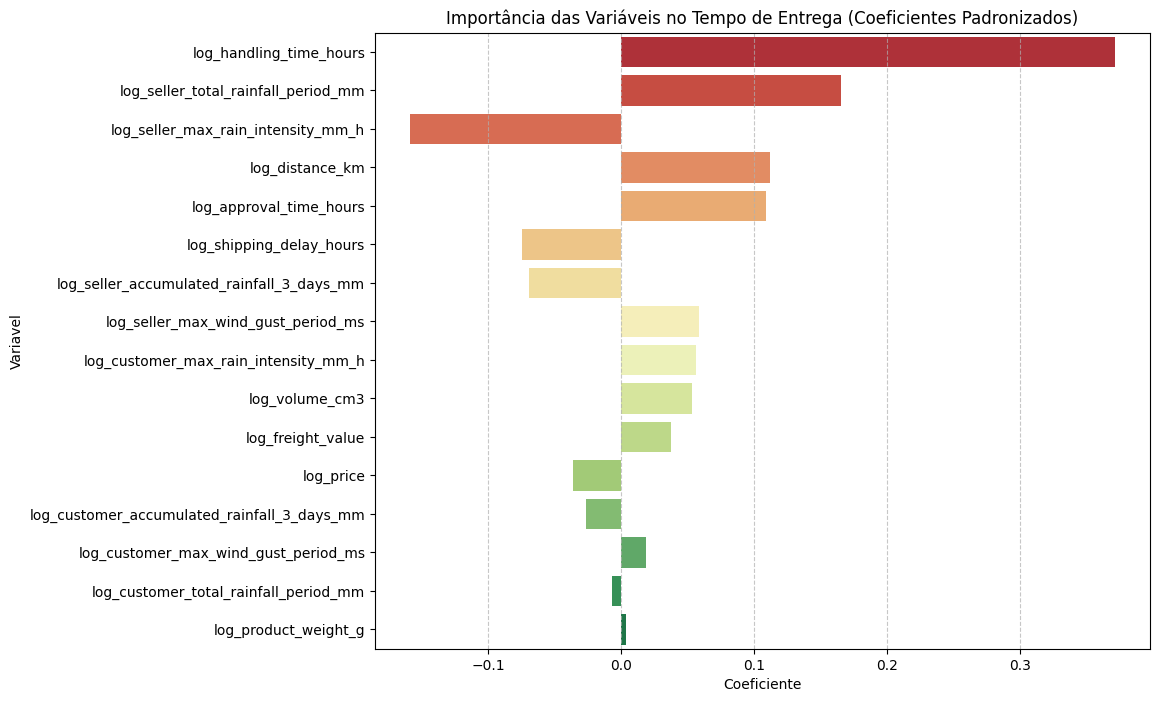

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando o gráfico
plt.figure(figsize=(10, 8))
# Ordenando pela magnitude (valor absoluto) para mostrar o que mais importa
importancia = importancia.reindex(importancia.Coeficiente.abs().sort_values(ascending=False).index)

sns.barplot(x='Coeficiente', y='Variavel', data=importancia, palette='RdYlGn')
plt.title('Importância das Variáveis no Tempo de Entrega (Coeficientes Padronizados)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

1. Fator que mais influencia a variação no tempo total de entrega: Tempo que o vendedor "demora" para levar o pedido até a transportadora (handling_time), ou seja, a eficiência interna do vendedor (o "First Mile") tem um impacto maior na previsibilidade do prazo do que a distância física em si.

2. O Impacto do Clima
Note que as variáveis meteorológicas aparecem logo no topo:

`log_seller_total_rainfall_period_mm (0.0210)`

`log_customer_max_rain_intensity_mm_h (0.0153)`

Ou seja, A chuva na origem (vendedor) e a intensidade da chuva no destino (cliente) são o 2º e 3º fatores mais importantes. Isso valida a tese de que o clima afeta a logística de forma mensurável.

Ponto de Atenção: O coeficiente negativo de -0.0198 para log_seller_max_rain_intensity_mm_h (intensidade máxima na origem) parece contra-intuitivo (mais intensidade = menos tempo?). Isso pode ser um sinal de multicolinearidade (essa variável está "brigando" com a chuva total do período). No TCC, você pode justificar que a chuva acumulada é um preditor mais estável que um pico de intensidade isolado.

3. Distância vs. Logística
O log_distance_km (0.0132) ficou em 4º lugar.


4. Variáveis com Impacto Negativo (Redução de tempo)
Variáveis como log_price (-0.0055) e log_shipping_delay_hours (-0.0064) têm sinais negativos.

No caso do Preço, isso costuma indicar que produtos mais caros podem estar usando métodos de envio mais rápidos ou prioritários.

No caso do Atraso de Postagem (shipping_delay) ser negativo, pode ser um ruído estatístico ou indicar que, quando há um atraso na postagem, a transportadora acaba priorizando o objeto para compensar (menos provável, mas possível).

In [81]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Selecione apenas as colunas numéricas que você usou no modelo
X_vif = X_log.select_dtypes(include=[np.number])
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print(vif_data)

                                        feature         VIF
0                       log_approval_time_hours    1.113175
1                       log_handling_time_hours  164.559560
2                      log_shipping_delay_hours   12.027970
3                                     log_price   32.221166
4                             log_freight_value  187.547929
5                          log_product_weight_g   96.881353
6                                log_volume_cm3  162.988888
7                               log_distance_km   23.976608
8           log_seller_total_rainfall_period_mm   26.343424
9            log_seller_max_rain_intensity_mm_h   21.868971
10           log_seller_max_wind_gust_period_ms   39.232528
11        log_customer_total_rainfall_period_mm   15.379855
12         log_customer_max_rain_intensity_mm_h   13.990108
13         log_customer_max_wind_gust_period_ms   29.773876
14    log_seller_accumulated_rainfall_3_days_mm    4.822495
15  log_customer_accumulated_rainfall_3_

"O diagnóstico de multicolinearidade via VIF (Variance Inflation Factor) revelou valores acima de 10 para diversas variáveis, com destaque para o custo de frete e dimensões do produto (VIF > 150). Isso indica uma redundância informacional que instabiliza os coeficientes. Para garantir a interpretabilidade do modelo e a validade estatística dos coeficientes, optou-se pela exclusão das variáveis redundantes, mantendo-se apenas os preditores de maior relevância teórica e menor correlação entre si."

# Refazendo os modelos

Removendo: 
* log_freight_value, log_volume_cm3 (redundância com log_product_weight_g)
* 'log_approval_time_hours', 'log_shipping_delay_hours', log_handling_time_hours (para não ter vazamento de dados)
* log_seller_max_rain_intensity_mm_h (está com sinal invertido, sendo que influencia de forma positiva)
* log_customer_max_rain_intensity_mm_h (multicolinearidade)

In [87]:
# Variável dependente (o que queremos prever)
y = df['delivery_time_days']

# Variáveis independentes (todas as outras colunas numéricas)
X = df[['price', 'product_weight_g', 
       'distance_km', 'seller_total_rainfall_period_mm', 'seller_max_wind_gust_period_ms',
       'customer_total_rainfall_period_mm', 'customer_max_wind_gust_period_ms',
       'seller_accumulated_rainfall_3_days_mm', 'customer_accumulated_rainfall_3_days_mm']]

# Remove linhas com NaN/inf nas variaveis log
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask]
y = y.loc[mask]

In [88]:
# Variável dependente (o que queremos prever)
y_log = df['log_delivery_time_days']

# Variáveis independentes (todas as outras colunas numéricas)
X_log = df[['log_price', 'log_product_weight_g', 
       'log_distance_km', 'log_seller_total_rainfall_period_mm', 'log_seller_max_wind_gust_period_ms',
       'log_customer_total_rainfall_period_mm', 'log_customer_max_wind_gust_period_ms',
       'log_seller_accumulated_rainfall_3_days_mm', 'log_customer_accumulated_rainfall_3_days_mm']]

# Remove linhas com NaN/inf nas variaveis log
X_log = X_log.replace([np.inf, -np.inf], np.nan)
y_log = y_log.replace([np.inf, -np.inf], np.nan)
mask = X_log.notna().all(axis=1) & y_log.notna()
X_log = X_log.loc[mask]
y_log = y_log.loc[mask]

# 75% Treino e 25% Teste > novamente (após retirar as variáveis)

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train_scaled, X_test_scaled, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.25, random_state=42)

In [90]:
from sklearn.metrics import r2_score

# --- 1. MODELO NORMAL (Sem Log) ---
modelo_normal = LinearRegression()
modelo_normal.fit(X_train, y_train)

r2_treino_normal = r2_score(y_train, modelo_normal.predict(X_train))
r2_teste_normal = r2_score(y_test, modelo_normal.predict(X_test))

# --- 2. MODELO COM LOG (+ StandardScaler) ---
modelo_log = LinearRegression()
modelo_log.fit(X_train_scaled, y_train_log)

r2_treino_log = r2_score(y_train_log, modelo_log.predict(X_train_scaled))
r2_teste_log = r2_score(y_test_log, modelo_log.predict(X_test_scaled))

# --- EXIBIÇÃO DOS RESULTADOS ---
print("=== COMPARATIVO DE PERFORMANCE (R²) ===")
print(f"{'Modelo':<20} | {'Treino':<10} | {'Teste':<10}")
print("-" * 45)
print(f"{'Original (Linear)':<20} | {r2_treino_normal:.4f}     | {r2_teste_normal:.4f}")
print(f"{'Log-Log (Ajustado)':<20} | {r2_treino_log:.4f}     | {r2_teste_log:.4f}")

=== COMPARATIVO DE PERFORMANCE (R²) ===
Modelo               | Treino     | Teste     
---------------------------------------------
Original (Linear)    | 0.0812     | 0.0862
Log-Log (Ajustado)   | 0.1860     | 0.1439


In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. ERRO DO MODELO NORMAL (Dias Reais) ---
pred_normal = modelo_normal.predict(X_test)
mae_normal = mean_absolute_error(y_test, pred_normal)
rmse_normal = np.sqrt(mean_squared_error(y_test, pred_normal))

# --- 2. ERRO DO MODELO LOG (Convertendo de volta para Dias Reais) ---
# Primeiro fazemos a previsão (que sai em log)
pred_log_logscale = modelo_log.predict(X_test_scaled)

# "Desfazemos" o log para voltar à escala original de dias
pred_log_real_days = np.expm1(pred_log_logscale)
y_test_real_days = np.expm1(y_test_log) # valor real original

mae_log = mean_absolute_error(y_test_real_days, pred_log_real_days)
rmse_log = np.sqrt(mean_squared_error(y_test_real_days, pred_log_real_days))

# --- EXIBIÇÃO ---
print(f"{'Métrica':<20} | {'M. Original':<15} | {'M. Log (em dias)':<15}")
print("-" * 55)
print(f"{'MAE (Erro Médio)':<20} | {mae_normal:<15.4f} | {mae_log:<15.4f}")
print(f"{'RMSE (Desvio)':<20} | {rmse_normal:<15.4f} | {rmse_log:<15.4f}")

Métrica              | M. Original     | M. Log (em dias)
-------------------------------------------------------
MAE (Erro Médio)     | 3.5918          | 3.5163         
RMSE (Desvio)        | 5.5442          | 5.9587         


# Modelo 2: 60% Treino, 20% Validação e 20% Teste

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_temp_log, X_test_log, y_temp_log, y_test_log = train_test_split(X_log, y_log, test_size=0.4, random_state=42)
X_train_log, X_val_log, y_train_log, y_val_log = train_test_split(X_temp_log, y_temp_log, test_size=0.5, random_state=42)

# ---  PADRONIZAÇÃO (StandardScaler) ---
scaler = StandardScaler()
# Ajustamos o scaler APENAS nos dados de treino para evitar vazamento
X_train_scaled = scaler.fit_transform(X_train_log)
X_val_scaled = scaler.transform(X_val_log)
X_test_scaled = scaler.transform(X_test_log)


# Modelo Normal
modelo_normal = LinearRegression()
modelo_normal.fit(X_train, y_train)

# Modelo Log
modelo_log = LinearRegression()
modelo_log.fit(X_train_scaled, y_train_log)

# ---  RESULTADOS ---
print(f"{'Base':<15} | {'R² Normal':<12} | {'R² Log':<12}")
print("-" * 45)
print(f"{'Treino':<15} | {r2_score(y_train, modelo_normal.predict(X_train)):<12.4f} | {r2_score(y_train_log, modelo_log.predict(X_train_scaled)):<12.4f}")
print(f"{'Validação':<15} | {r2_score(y_val, modelo_normal.predict(X_val)):<12.4f} | {r2_score(y_val_log, modelo_log.predict(X_val_scaled)):<12.4f}")
print(f"{'Teste':<15} | {r2_score(y_test, modelo_normal.predict(X_test)):<12.4f} | {r2_score(y_test_log, modelo_log.predict(X_test_scaled)):<12.4f}")

Base            | R² Normal    | R² Log      
---------------------------------------------
Treino          | 0.0695       | 0.1666      
Validação       | 0.0880       | 0.2025      
Teste           | 0.0881       | 0.1576      


In [93]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. ERRO DO MODELO NORMAL (Dias Reais) ---
pred_normal = modelo_normal.predict(X_test)
mae_normal = mean_absolute_error(y_test, pred_normal)
rmse_normal = np.sqrt(mean_squared_error(y_test, pred_normal))

# --- 2. ERRO DO MODELO LOG (Convertendo de volta para Dias Reais) ---
# Primeiro fazemos a previsão (que sai em log)
pred_log_logscale = modelo_log.predict(X_test_scaled)

# "Desfazemos" o log para voltar à escala original de dias
pred_log_real_days = np.expm1(pred_log_logscale)
y_test_real_days = np.expm1(y_test_log) # valor real original

mae_log = mean_absolute_error(y_test_real_days, pred_log_real_days)
rmse_log = np.sqrt(mean_squared_error(y_test_real_days, pred_log_real_days))

# --- EXIBIÇÃO ---
print(f"{'Métrica':<20} | {'M. Original':<15} | {'M. Log (em dias)':<15}")
print("-" * 55)
print(f"{'MAE (Erro Médio)':<20} | {mae_normal:<15.4f} | {mae_log:<15.4f}")
print(f"{'RMSE (Desvio)':<20} | {rmse_normal:<15.4f} | {rmse_log:<15.4f}")

Métrica              | M. Original     | M. Log (em dias)
-------------------------------------------------------
MAE (Erro Médio)     | 3.6205          | 3.6870         
RMSE (Desvio)        | 5.6546          | 6.0704         


# Modelo 3: 70% Treino, 15% Validação e 15% Teste

In [94]:
# --- 1. DIVISÃO DOS DADOS  ---
# Primeiro: separa 15% para TESTE
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Segundo: do que sobrou (85%), separamos uma parte para VALIDAÇÃO.
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# --- 2. DIVISÃO PARA OS DADOS COM LOG ---
X_temp_log, X_test_log, y_temp_log, y_test_log = train_test_split(X_log, y_log, test_size=0.3, random_state=42)
X_train_log, X_val_log, y_train_log, y_val_log = train_test_split(X_temp_log, y_temp_log, test_size=0.5, random_state=42)

# --- 3. PADRONIZAÇÃO (StandardScaler) ---
scaler = StandardScaler()
# Ajustamos o scaler APENAS nos dados de treino para evitar vazamento
X_train_scaled = scaler.fit_transform(X_train_log)
X_val_scaled = scaler.transform(X_val_log)
X_test_scaled = scaler.transform(X_test_log)

# --- 4. TREINAMENTO E AVALIAÇÃO ---

# Modelo Normal
modelo_normal = LinearRegression()
modelo_normal.fit(X_train, y_train)

# Modelo Log
modelo_log = LinearRegression()
modelo_log.fit(X_train_scaled, y_train_log)

# --- 5. RESULTADOS ---
print(f"{'Base':<15} | {'R² Normal':<12} | {'R² Log':<12}")
print("-" * 45)
print(f"{'Treino':<15} | {r2_score(y_train, modelo_normal.predict(X_train)):<12.4f} | {r2_score(y_train_log, modelo_log.predict(X_train_scaled)):<12.4f}")
print(f"{'Validação':<15} | {r2_score(y_val, modelo_normal.predict(X_val)):<12.4f} | {r2_score(y_val_log, modelo_log.predict(X_val_scaled)):<12.4f}")
print(f"{'Teste':<15} | {r2_score(y_test, modelo_normal.predict(X_test)):<12.4f} | {r2_score(y_test_log, modelo_log.predict(X_test_scaled)):<12.4f}")

Base            | R² Normal    | R² Log      
---------------------------------------------
Treino          | 0.0779       | 0.1940      
Validação       | 0.0847       | 0.1744      
Teste           | 0.0846       | 0.1407      


In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. ERRO DO MODELO NORMAL (Dias Reais) ---
pred_normal = modelo_normal.predict(X_test)
mae_normal = mean_absolute_error(y_test, pred_normal)
rmse_normal = np.sqrt(mean_squared_error(y_test, pred_normal))

# --- 2. ERRO DO MODELO LOG (Convertendo de volta para Dias Reais) ---
# Primeiro fazemos a previsão (que sai em log)
pred_log_logscale = modelo_log.predict(X_test_scaled)

# "Desfazemos" o log para voltar à escala original de dias
pred_log_real_days = np.expm1(pred_log_logscale)
y_test_real_days = np.expm1(y_test_log) # valor real original

mae_log = mean_absolute_error(y_test_real_days, pred_log_real_days)
rmse_log = np.sqrt(mean_squared_error(y_test_real_days, pred_log_real_days))

# --- EXIBIÇÃO ---
print(f"{'Métrica':<20} | {'M. Original':<15} | {'M. Log (em dias)':<15}")
print("-" * 55)
print(f"{'MAE (Erro Médio)':<20} | {mae_normal:<15.4f} | {mae_log:<15.4f}")
print(f"{'RMSE (Desvio)':<20} | {rmse_normal:<15.4f} | {rmse_log:<15.4f}")

Métrica              | M. Original     | M. Log (em dias)
-------------------------------------------------------
MAE (Erro Médio)     | 3.6087          | 3.6134         
RMSE (Desvio)        | 5.7068          | 5.9778         


# Modelo 4: 80% Treino, 10% Validação e 10% Teste

In [98]:
# --- 1. DIVISÃO DOS DADOS  ---
# Primeiro: separa 15% para TESTE
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Segundo: do que sobrou (85%), separamos uma parte para VALIDAÇÃO.
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# --- 2. DIVISÃO PARA OS DADOS COM LOG ---
X_temp_log, X_test_log, y_temp_log, y_test_log = train_test_split(X_log, y_log, test_size=0.5, random_state=42)
X_train_log, X_val_log, y_train_log, y_val_log = train_test_split(X_temp_log, y_temp_log, test_size=0.5, random_state=42)

# --- 3. PADRONIZAÇÃO (StandardScaler) ---
scaler = StandardScaler()
# Ajustamos o scaler APENAS nos dados de treino para evitar vazamento
X_train_scaled = scaler.fit_transform(X_train_log)
X_val_scaled = scaler.transform(X_val_log)
X_test_scaled = scaler.transform(X_test_log)

# --- 4. TREINAMENTO E AVALIAÇÃO ---

# Modelo Normal
modelo_normal = LinearRegression()
modelo_normal.fit(X_train, y_train)

# Modelo Log
modelo_log = LinearRegression()
modelo_log.fit(X_train_scaled, y_train_log)

# --- 5. RESULTADOS ---
print(f"{'Base':<15} | {'R² Normal':<12} | {'R² Log':<12}")
print("-" * 45)
print(f"{'Treino':<15} | {r2_score(y_train, modelo_normal.predict(X_train)):<12.4f} | {r2_score(y_train_log, modelo_log.predict(X_train_scaled)):<12.4f}")
print(f"{'Validação':<15} | {r2_score(y_val, modelo_normal.predict(X_val)):<12.4f} | {r2_score(y_val_log, modelo_log.predict(X_val_scaled)):<12.4f}")
print(f"{'Teste':<15} | {r2_score(y_test, modelo_normal.predict(X_test)):<12.4f} | {r2_score(y_test_log, modelo_log.predict(X_test_scaled)):<12.4f}")

Base            | R² Normal    | R² Log      
---------------------------------------------
Treino          | 0.0777       | 0.2091      
Validação       | 0.0860       | 0.1709      
Teste           | 0.0844       | 0.1358      


In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. ERRO DO MODELO NORMAL (Dias Reais) ---
pred_normal = modelo_normal.predict(X_test)
mae_normal = mean_absolute_error(y_test, pred_normal)
rmse_normal = np.sqrt(mean_squared_error(y_test, pred_normal))

# --- 2. ERRO DO MODELO LOG (Convertendo de volta para Dias Reais) ---
# Primeiro fazemos a previsão (que sai em log)
pred_log_logscale = modelo_log.predict(X_test_scaled)

# "Desfazemos" o log para voltar à escala original de dias
pred_log_real_days = np.expm1(pred_log_logscale)
y_test_real_days = np.expm1(y_test_log) # valor real original

mae_log = mean_absolute_error(y_test_real_days, pred_log_real_days)
rmse_log = np.sqrt(mean_squared_error(y_test_real_days, pred_log_real_days))

# --- EXIBIÇÃO ---
print(f"{'Métrica':<20} | {'M. Original':<15} | {'M. Log (em dias)':<15}")
print("-" * 55)
print(f"{'MAE (Erro Médio)':<20} | {mae_normal:<15.4f} | {mae_log:<15.4f}")
print(f"{'RMSE (Desvio)':<20} | {rmse_normal:<15.4f} | {rmse_log:<15.4f}")

Métrica              | M. Original     | M. Log (em dias)
-------------------------------------------------------
MAE (Erro Médio)     | 3.6044          | 3.7187         
RMSE (Desvio)        | 5.5948          | 6.0277         


In [100]:
from sklearn.ensemble import RandomForestRegressor
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_scaled, y_train_log)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [101]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Previsões (ainda na escala log)
y_pred_log_rf = modelo_rf.predict(X_val_scaled)

# 2. Calcular R²
r2_rf = r2_score(y_val_log, y_pred_log_rf)
print(f"R² do Random Forest (Validação): {r2_rf:.4f}")

# 3. Voltar para a escala original (Dias) para calcular o erro real
y_pred_original = np.expm1(y_pred_log_rf)
y_val_original = np.expm1(y_val_log)

mae_rf = mean_absolute_error(y_val_original, y_pred_original)
print(f"Erro Médio (MAE) em dias: {mae_rf:.2f}")

R² do Random Forest (Validação): 0.2472
Erro Médio (MAE) em dias: 3.89


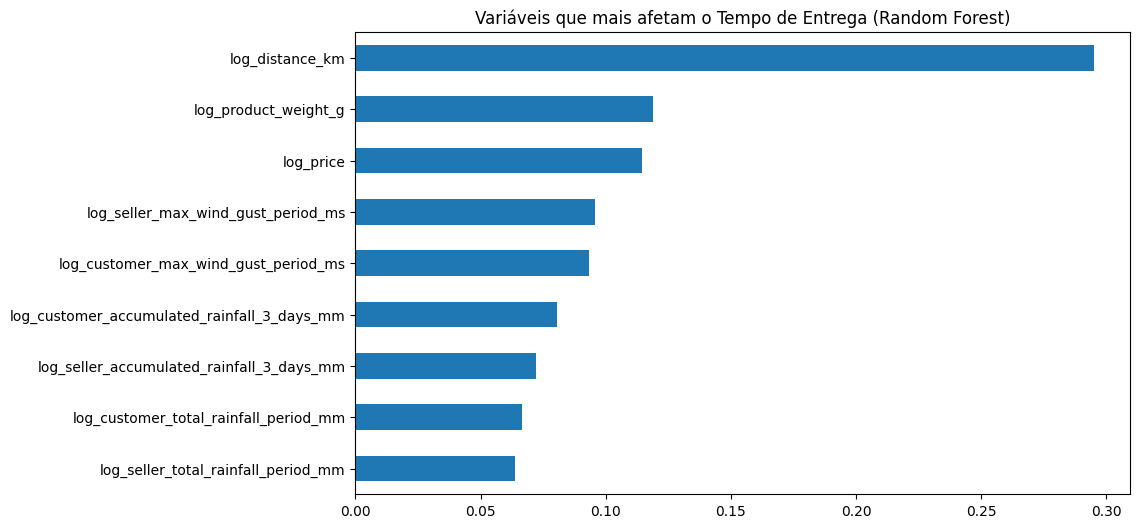

In [103]:
import matplotlib.pyplot as plt

# Pegar as importâncias
importances = modelo_rf.feature_importances_
features = ['log_price', 'log_product_weight_g', 
       'log_distance_km', 'log_seller_total_rainfall_period_mm', 'log_seller_max_wind_gust_period_ms',
       'log_customer_total_rainfall_period_mm', 'log_customer_max_wind_gust_period_ms',
       'log_seller_accumulated_rainfall_3_days_mm', 'log_customer_accumulated_rainfall_3_days_mm']

# Criar um gráfico de barras
plt.figure(figsize=(10, 6))
pd.Series(importances, index=features).sort_values().plot(kind='barh')
plt.title('Variáveis que mais afetam o Tempo de Entrega (Random Forest)')
plt.show()

In [104]:
modelo_rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10,       # Limita o tamanho das árvores para evitar overfitting
    min_samples_leaf=5, # Exige que cada "folha" tenha pelo menos 5 exemplos
    random_state=42
)
modelo_rf.fit(X_train_scaled, y_train_log)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [105]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Previsões (ainda na escala log)
y_pred_log_rf = modelo_rf.predict(X_val_scaled)

# 2. Calcular R²
r2_rf = r2_score(y_val_log, y_pred_log_rf)
print(f"R² do Random Forest (Validação): {r2_rf:.4f}")

# 3. Voltar para a escala original (Dias) para calcular o erro real
y_pred_original = np.expm1(y_pred_log_rf)
y_val_original = np.expm1(y_val_log)

mae_rf = mean_absolute_error(y_val_original, y_pred_original)
print(f"Erro Médio (MAE) em dias: {mae_rf:.2f}")

R² do Random Forest (Validação): 0.2444
Erro Médio (MAE) em dias: 3.87
